/Users/juanhorma97/vector_graphRAG/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/jq/n5dydm097xg64llsh45jkxmm0000gn/T/ipykernel_82227/2885273079.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=breakdown_df, x="system", y="avg_score", ax=ax_breakdown, palette="Set2")
/var/folders/jq/n5dydm097xg64llsh45jkxmm0000gn/T/ipykernel_82227/2885273079.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=breakdown_df, x="system", y="avg_score", ax=ax_breakdown, palette="Set2")
/var/fo

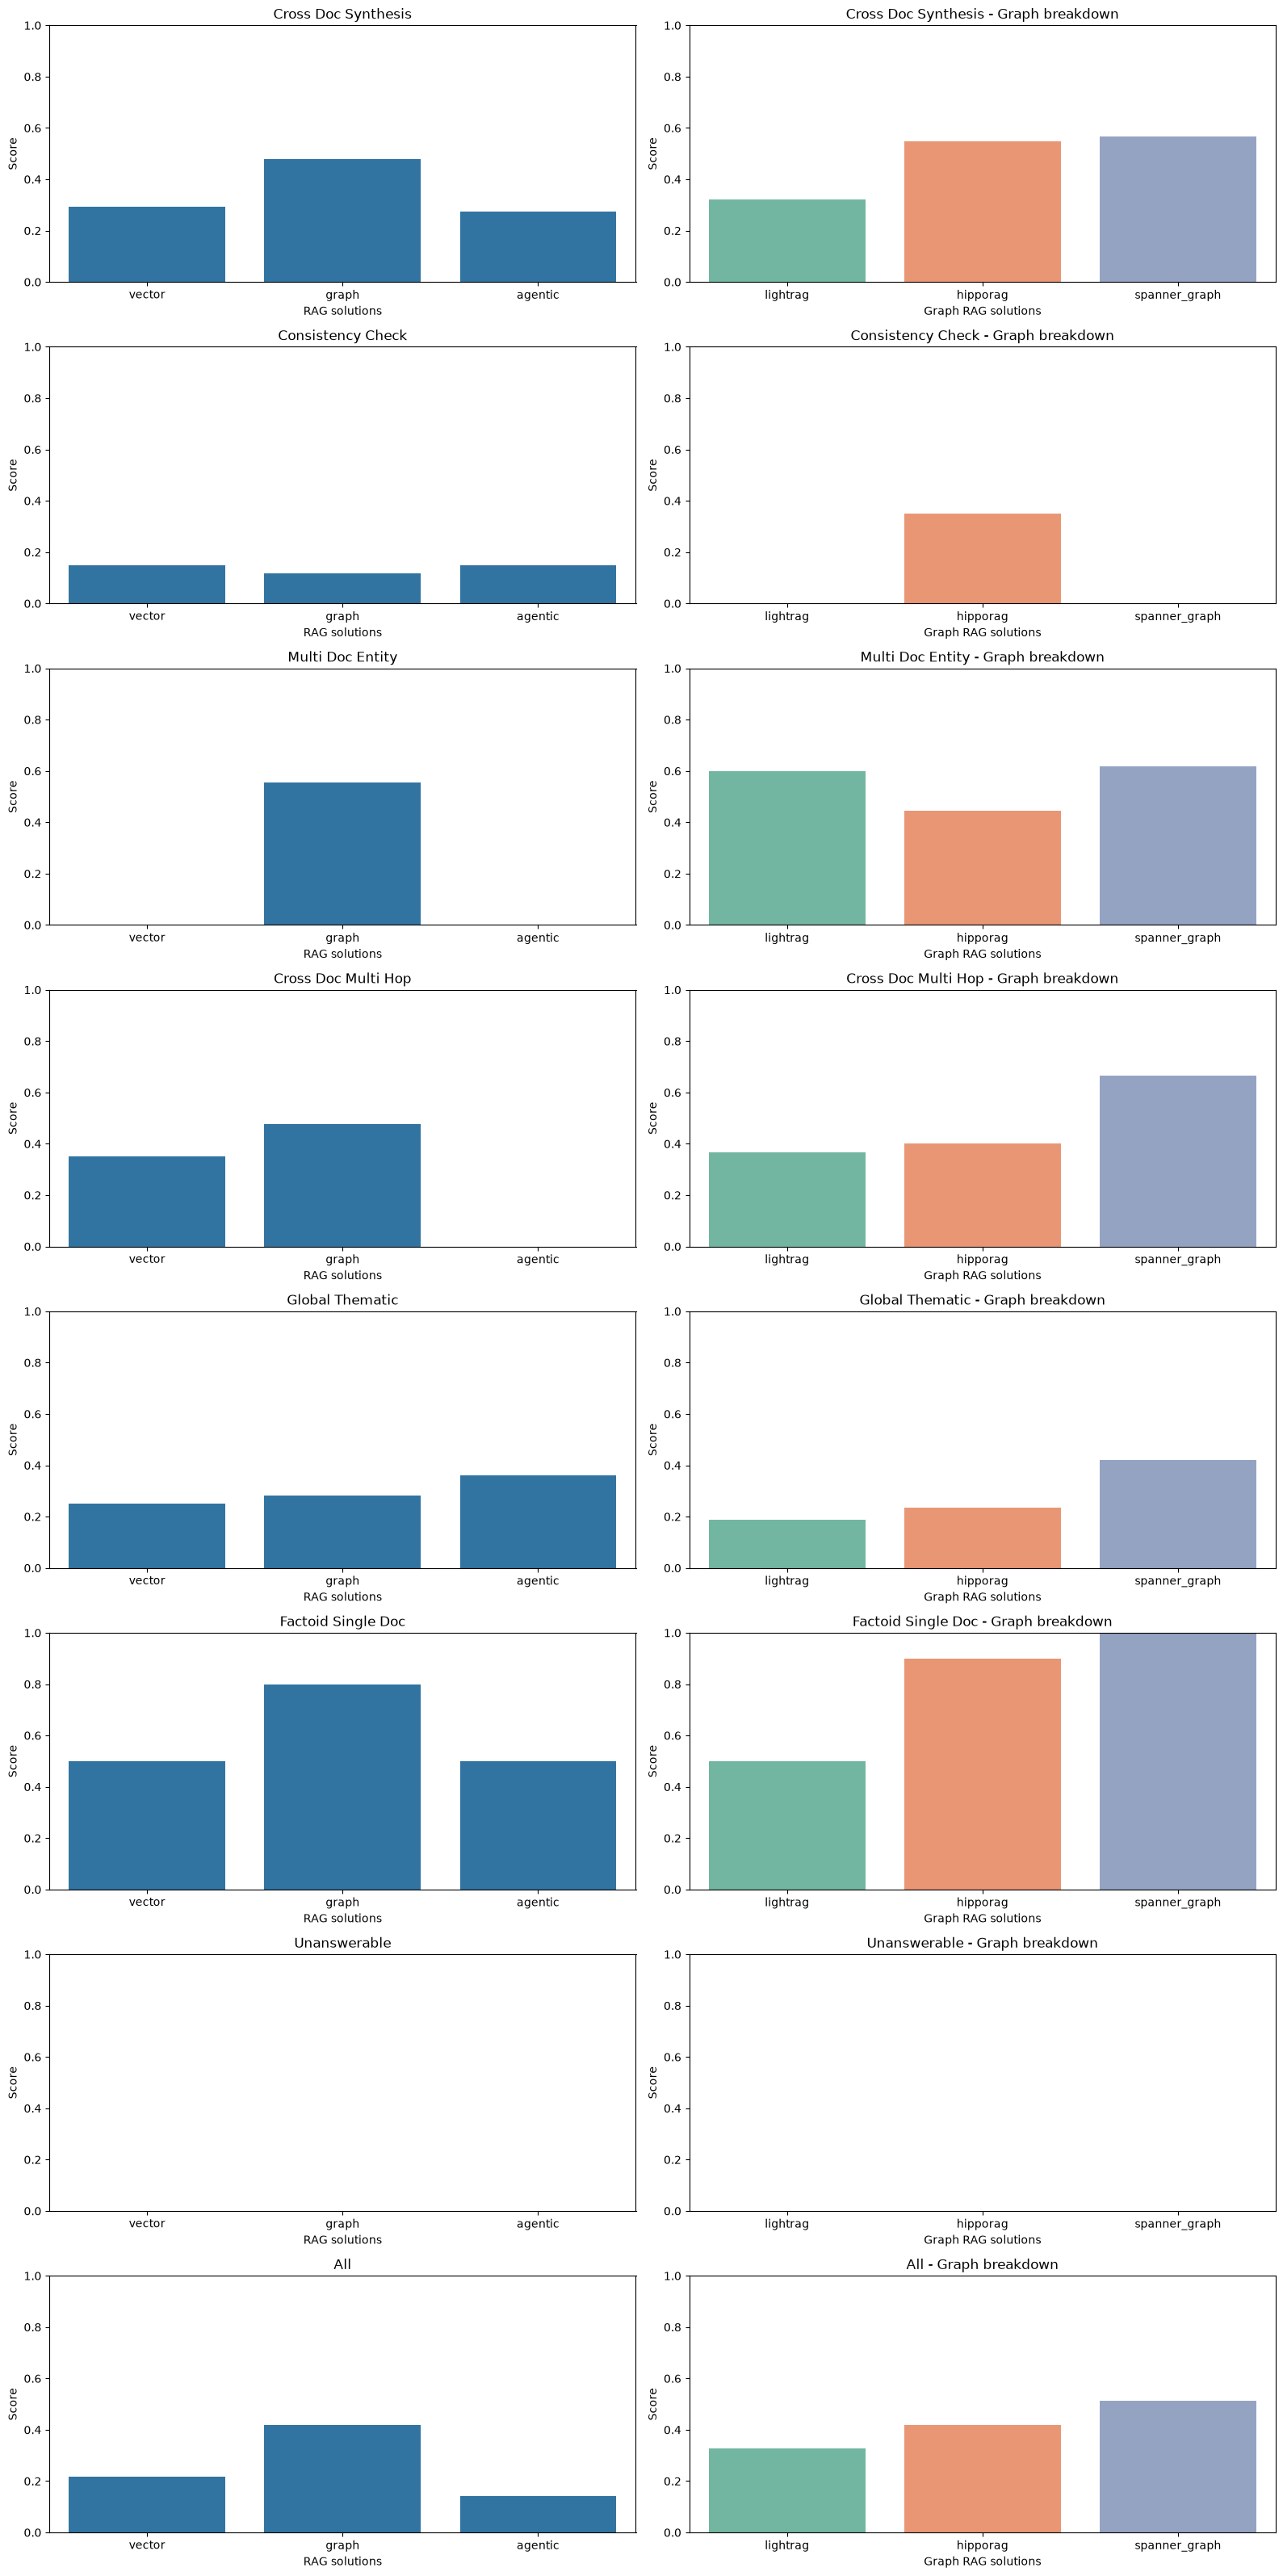

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import calculate_final_score

scorer_df = pd.read_csv("./templates/CrossDoc_RAG_Scoring_Template_v2.csv")
scoring_summary_df = pd.read_csv("./templates/CrossDoc_RAG_Scoring_Summary.csv")
strategies = ["vector_rag", "lightrag", "hipporag", "spanner_graph", "agentic_rag"]

PREFIX_MAP = {
    "vector_rag": "vector",
    "lightrag": "lightrag",
    "hipporag": "hipporag",
    "spanner_graph": "graph",
    "agentic_rag": "agentic"
}

for strategy in strategies:
    prefix = PREFIX_MAP[strategy]
    scorer_df[f"{prefix}_final_score"] = 0.0
    for i in range(scorer_df.shape[0]):
        q_type = scorer_df.at[i, "query_type"]
        use_recall = q_type in ["multi_doc_entity", "global_thematic"]
        
        final_score = calculate_final_score( # type: ignore
            faithfulness=scorer_df.at[i, f"{prefix}_faithful"], # type:ignore
            correctness=None if use_recall else scorer_df.at[i, f"{prefix}_correctness"], # type:ignore
            nugget_recall=scorer_df.at[i, f"{prefix}_nugget_recall"], # type:ignore
            retrieval=scorer_df.at[i, f"{prefix}_retrieval"], # type:ignore
            attribution=scorer_df.at[i, f"{prefix}_attribution"], # type:ignore
            unanswerable=(q_type == "unanswerable")
        )
        scorer_df.at[i, f"{prefix}_final_score"] = final_score

grouped_means = scorer_df.groupby("query_type").mean(numeric_only=True)

for i in range(scoring_summary_df.shape[0]):
    system = scoring_summary_df.at[i, "system"]
    q_type = scoring_summary_df.at[i, "query_type"]
    
    if system == "vector":
        score_cols, lat_cols, faith_cols = ["vector_final_score"], ["vector_latency_ms"], ["vector_faithful"]
    elif system == "agentic":
        score_cols, lat_cols, faith_cols = ["agentic_final_score"], ["agentic_latency_ms"], ["agentic_faithful"]
    elif system == "graph":
        score_cols = ["lightrag_final_score", "hipporag_final_score", "graph_final_score"]
        lat_cols = ["lightrag_latency_ms", "hipporag_latency_ms", "graph_latency_ms"]
        faith_cols = ["lightrag_faithful", "hipporag_faithful", "graph_faithful"]
    else:
        continue
        
    if q_type == "ALL":
        scoring_summary_df.at[i, "avg_score"] = scorer_df[score_cols].mean().mean()
        # scoring_summary_df.at[i, "avg_latency_ms"] = scorer_df[lat_cols].mean().mean()
        # scoring_summary_df.at[i, "faithfulness_rate"] = scorer_df[faith_cols].mean().mean()
    else:
        scoring_summary_df.at[i, "avg_score"] = grouped_means.loc[q_type, score_cols].mean() # type: ignore
        # scoring_summary_df.at[i, "avg_latency_ms"] = grouped_means.loc[q_type, lat_cols].mean() # type: ignore
        # scoring_summary_df.at[i, "faithfulness_rate"] = grouped_means.loc[q_type, faith_cols].mean() # type: ignore


scorer_df.to_csv("./templates/CrossDoc_RAG_Scoring_Template_v2.csv")

scoring_summary_df.to_csv("./templates/CrossDoc_RAG_Scoring_Summary.csv")
query_types = [
    "cross_doc_synthesis", "consistency_check", "multi_doc_entity", 
    "cross_doc_multi_hop", "global_thematic", "factoid_single_doc", "ALL"
]

fig, axes = plt.subplots(8, 2, figsize=(16, 32))
for (ax_main, ax_breakdown), q_type in zip(axes, query_types):
    subset = scoring_summary_df[scoring_summary_df["query_type"] == q_type]
    sns.barplot(data=subset, x="system", y="avg_score", ax=ax_main)
    ax_main.set_title(q_type.replace("_", " ").title())
    ax_main.set(xlabel="RAG solutions", ylabel="Score")
    ax_main.set_ylim(0.0, 1.0)
    if q_type == "ALL":
        breakdown_data = {
            "system": ["lightrag", "hipporag", "spanner_graph"],
            "avg_score": [
                scorer_df["lightrag_final_score"].mean(),
                scorer_df["hipporag_final_score"].mean(),
                scorer_df["graph_final_score"].mean()  
            ]
        }
    else:
        breakdown_data = {
            "system": ["lightrag", "hipporag", "spanner_graph"],
            "avg_score": [
                grouped_means.loc[q_type, "lightrag_final_score"],
                grouped_means.loc[q_type, "hipporag_final_score"],
                grouped_means.loc[q_type, "graph_final_score"] 
            ]
        }
    
    breakdown_df = pd.DataFrame(breakdown_data)
    sns.barplot(data=breakdown_df, x="system", y="avg_score", ax=ax_breakdown, palette="Set2")
    ax_breakdown.set_title(f"{q_type.replace('_', ' ').title()} - Graph breakdown")
    ax_breakdown.set(xlabel="Graph RAG solutions", ylabel="Score")
    ax_breakdown.set_ylim(0.0, 1.0)
plt.tight_layout()
plt.show()
